# Módulo 5 — Identificación de choques: VAR, Cholesky y BQ

**Curso complementario · puremacro**

### Objetivos de aprendizaje
Al terminar esta lección podrás:
1. Estimar un **VAR reducido** y explicar por qué, por sí solo, **no** identifica choques estructurales.
2. Identificar choques con el esquema recursivo de **Cholesky** (supuesto de *timing* contemporáneo).
3. Identificar choques con la restricción de **largo plazo de Blanchard–Quah (1989)**.
4. Leer una **función de impulso-respuesta (IRF)** y una **descomposición de varianza del error de pronóstico (FEVD)**.
5. Dada una IRF, **reconocer qué identificación se usó** y qué supuesto la sostiene.

Todo corre en Python puro sobre tu **instalación local** de `puremacro`
(`pip install puremacro`), con los módulos reales de `puremacro.var`.

In [1]:
import sys, pathlib
import numpy as np, pandas as pd
import matplotlib
try:  # bajo Jupyter/ipykernel: conserva el backend inline (captura figuras)
    get_ipython()
except NameError:
    matplotlib.use("Agg")  # script plano / CLI: backend no interactivo
import matplotlib.pyplot as plt
_here = pathlib.Path(__file__).resolve().parent if "__file__" in globals() else pathlib.Path.cwd()
_nb = _here if (_here / "_nbstyle.py").exists() else (_here.parent if (_here.parent / "_nbstyle.py").exists() else _here)
sys.path.insert(0, str(_nb)); sys.path.insert(0, str(_nb / "course"))
import _nbstyle; _nbstyle.apply_style()
from _tutor import tutor
DATA = (_here / "data") if (_here / "data").exists() else (_nb / "course" / "data")

## 1. El taller de identificación

Un **VAR reducido** de orden $p$ describe la dinámica conjunta de $n$ variables:
$$ y_t = c + A_1 y_{t-1} + \dots + A_p y_{t-p} + u_t, \qquad \operatorname{Cov}(u_t)=\Sigma. $$
Los residuos $u_t$ son útiles para pronosticar, pero **no tienen interpretación económica**:
son mezclas de los choques estructurales $\varepsilon_t$ (tecnología, política monetaria,
demanda…) que realmente nos interesan.

### El problema de la rotación
Suponemos que los residuos son combinaciones lineales de choques ortonormales,
$u_t = B_0\,\varepsilon_t$ con $\operatorname{Var}(\varepsilon_t)=I$, de modo que
$$ \Sigma = B_0 B_0'. $$
El obstáculo: $B_0$ **no es único**. Para cualquier matriz ortogonal $Q$ (con $QQ'=I$),
la matriz $B_0 Q$ reproduce el mismo $\Sigma$. Hacen falta $n(n-1)/2$ **restricciones
extra** para fijar $B_0$. *Identificar* = elegir esas restricciones. Veremos dos recetas
clásicas — **Cholesky** (timing contemporáneo) y **Blanchard–Quah** (largo plazo) — y
cómo el mismo dato produce IRF distintas según el supuesto.

## 2. Los datos: Galí (1999)
Usamos el conjunto clásico de la literatura tecnología–horas (series de EE. UU., sector
empresarial no agrícola):
- `ophnfb` — **productividad laboral** (producto por hora).
- `hoanbs` — **horas** trabajadas (índice agregado).
- `cnp16ov` — **población** civil de 16+ años (para pasar a términos per cápita).

Construimos dos series estacionarias en **tasas de crecimiento** (100·Δlog): la
productividad laboral y las horas per cápita. Ambas son insumos naturales de un VAR
bivariado tecnología–horas.

In [2]:
df = pd.read_csv(DATA / "gali1999.csv", parse_dates=["date"])

log_prod = np.log(df["ophnfb"].to_numpy())                 # productividad laboral (log)
log_hours = np.log((df["hoanbs"] / df["cnp16ov"]).to_numpy())  # horas per cápita (log)

dprod = 100.0 * np.diff(log_prod)     # crecimiento de la productividad
dhours = 100.0 * np.diff(log_hours)   # crecimiento de las horas per cápita
Y = np.column_stack([dprod, dhours])  # columna 0 = productividad, columna 1 = horas
labels = ["productividad", "horas"]

print(f"muestra: {df['date'].iloc[1].date()} … {df['date'].iloc[-1].date()}  (T={Y.shape[0]})")
print(f"medias (% trimestral): productividad={Y[:,0].mean():.2f}, horas={Y[:,1].mean():.2f}")
print(f"desviaciones estándar : productividad={Y[:,0].std():.2f}, horas={Y[:,1].std():.2f}")

muestra: 1948-04-01 … 2026-01-01  (T=312)
medias (% trimestral): productividad=0.53, horas=-0.02
desviaciones estándar : productividad=0.85, horas=1.30


## 3. El VAR reducido
Elegimos rezagos y estimamos por MCO. `fit_var` (alias público de `estimate_var`)
devuelve un objeto con `A_list`, `c`, `Sigma`, `resid`. La matriz $\Sigma$ es el punto de
partida de toda identificación: fuera de la diagonal captura el **comovimiento**
contemporáneo de los residuos que aún debemos "desenredar".

**Sobre los rezagos.** El BIC pide muy pocos rezagos en estas series; nosotros fijamos
$p=4$ porque es la elección de Galí (1999) y el estándar trimestral de esta literatura.
No es un detalle inocuo: el criterio de información y la convención de la literatura no
coinciden, y la lección imprime ambos para que lo veas.

In [3]:
from puremacro.var import fit_var, lag_select, is_stable, fevd, bootstrap_bands
from puremacro.var.identify import cholesky, bq
from puremacro.var.identify.cholesky import cholesky_factor

p_bic = lag_select(Y, maxlags=8, ic="bic")
p = 4  # convención trimestral de la literatura tecnología–horas
res = fit_var(Y, p)

print(f"rezagos sugeridos por BIC = {p_bic}; usamos p = {p} (estándar trimestral)")
print(f"VAR estable (raíces dentro del círculo unitario): {is_stable(res.A_list)}")
print("Sigma (covarianza de residuos reducidos):")
print(np.round(res.Sigma, 3))
print(f"correlación contemporánea de residuos = "
      f"{res.Sigma[0,1] / np.sqrt(res.Sigma[0,0]*res.Sigma[1,1]):+.2f}")

rezagos sugeridos por BIC = 1; usamos p = 4 (estándar trimestral)
VAR estable (raíces dentro del círculo unitario): True
Sigma (covarianza de residuos reducidos):
[[ 0.685 -0.131]
 [-0.131  1.542]]
correlación contemporánea de residuos = -0.13


## 4. Identificación 1 — Cholesky (recursiva)
**Receta:** exigir que $B_0$ sea **triangular inferior**. Con el orden
`[productividad, horas]`, la variable de arriba responde en el mismo trimestre **solo a
su propio choque**; el choque de horas afecta a la productividad **solo con rezago**.

**Supuesto que la sostiene:** un ordenamiento de *timing* contemporáneo. Es una hipótesis
sobre qué variable puede reaccionar dentro del trimestre. Cambiar el orden cambia los
choques.

In [4]:
H = 20
ch = cholesky(Y, p=p, horizon=H, n_boot=400, ci=0.9, seed=7)
print(ch.summary())
# irf_point[h, i, j] = respuesta de la variable i, al choque j, en el horizonte h
print(f"impacto (h=0) de la productividad al choque de horas = "
      f"{ch.irf_point[0, 0, 1]:.3f}  ->  cero por construcción (restricción recursiva)")

Cholesky SVAR result
  variables (n)     : 2
  horizon (H)       : 20
  CI level          : 0.90
  bootstrap draws   : 400 (dropped 0, 0.0%)

impacto (h=0) de la productividad al choque de horas = 0.000  ->  cero por construcción (restricción recursiva)


## 5. Identificación 2 — Blanchard–Quah (largo plazo)
**Receta:** exigir que la matriz de impacto **acumulado** (largo plazo) sea triangular.
Solo el choque "permanente" (aquí, el de **tecnología**) tiene efecto de largo plazo sobre
la productividad; el otro choque tiene efecto de largo plazo **nulo** sobre ella.

**Supuesto que la sostiene:** una restricción teórica de **largo plazo** (Blanchard–Quah,
1989; Galí, 1999). No dice nada sobre el timing contemporáneo — solo sobre a dónde
converge el sistema. `permanent_var_idx=0` señala la productividad como la variable de
efecto permanente. `bq_svar` devuelve la IRF **acumulada** de **todas** las variables:
como $Y$ está en tasas de crecimiento ($100\cdot\Delta\log$), la IRF acumulada es la
respuesta del **nivel**, en por ciento.

In [5]:
bqr = bq(Y, p=p, horizon=H, permanent_var_idx=0, n_boot=400, ci=0.9, seed=7)
print(bqr.summary())
print(f"efecto acumulado a h={H} del choque NO tecnológico sobre la productividad = "
      f"{bqr.irf_point[H, 0, 1]:+.4f}  ->  ~0: la restricción es a horizonte infinito y a "
      f"h={H} ya está prácticamente saturada")
print(f"respuesta de horas al choque de tecnología en el impacto (h=0) = "
      f"{bqr.irf_point[0, 1, 0]:+.2f} %  ->  las horas CAEN (resultado de Galí, 1999)")

Blanchard-Quah SVAR result
  variables (n)     : 2
  horizon (H)       : 20
  CI level          : 0.90
  bootstrap draws   : 400 (dropped 0, 0.0%)

efecto acumulado a h=20 del choque NO tecnológico sobre la productividad = -0.0003  ->  ~0: la restricción es a horizonte infinito y a h=20 ya está prácticamente saturada
respuesta de horas al choque de tecnología en el impacto (h=0) = -0.84 %  ->  las horas CAEN (resultado de Galí, 1999)


### Cuidado con la muestra: el −0.84 % no es "el número de Galí"
Nuestra muestra llega a 2026 e incluye el desplome de horas de 2020. La muestra estándar
del debate es la **previa a la Gran Recesión** (corte en 2007Q4). Repetimos ahí la misma
identificación: el signo sobrevive, pero la magnitud es **mucho menor**. El titular
"las horas caen" es robusto; su tamaño **no** lo es.

In [6]:
d07 = df.loc[df["date"] <= "2007-12-31"]
lp07 = np.log(d07["ophnfb"].to_numpy())
lh07 = np.log((d07["hoanbs"] / d07["cnp16ov"]).to_numpy())
Y07 = np.column_stack([100.0 * np.diff(lp07), 100.0 * np.diff(lh07)])
bq07 = bq(Y07, p=p, horizon=H, permanent_var_idx=0, n_boot=200, ci=0.9, seed=7)

print(f"muestra completa ({df['date'].iloc[1].date()}…{df['date'].iloc[-1].date()}, "
      f"T={Y.shape[0]:3d}): horas en impacto = {bqr.irf_point[0,1,0]:+.2f} % "
      f"[{bqr.irf_lower[0,1,0]:+.2f}, {bqr.irf_upper[0,1,0]:+.2f}]")
print(f"corte pre-2008   ({d07['date'].iloc[1].date()}…{d07['date'].iloc[-1].date()}, "
      f"T={Y07.shape[0]:3d}): horas en impacto = {bq07.irf_point[0,1,0]:+.2f} % "
      f"[{bq07.irf_lower[0,1,0]:+.2f}, {bq07.irf_upper[0,1,0]:+.2f}]")
print("-> mismo signo y banda al 90% por debajo de cero en ambos casos; "
      "la magnitud completa está dominada por 2020")

muestra completa (1948-04-01…2026-01-01, T=312): horas en impacto = -0.84 % [-1.37, -0.28]
corte pre-2008   (1948-04-01…2007-10-01, T=239): horas en impacto = -0.24 % [-0.39, -0.05]
-> mismo signo y banda al 90% por debajo de cero en ambos casos; la magnitud completa está dominada por 2020


## 6. Misma data, dos IRF
Comparamos la respuesta al **choque 0** (la "productividad ordenada primero" en Cholesky;
el "choque permanente/tecnológico" en BQ). No hay ninguna razón para que coincidan:
coincidirían solo si el dato satisficiera **a la vez** las dos restricciones (cero de
impacto y cero de largo plazo), lo cual sería una casualidad. Que difieran es justamente
el punto de la lección.

**Antes de comparar hay que igualar las unidades.** `bq_svar` devuelve la IRF ya
**acumulada** (nivel); `cholesky_svar` la devuelve **sin acumular** (tasa de crecimiento
trimestral). Graficarlas juntas tal cual compararía peras con manzanas, y la mayor parte
de la "diferencia" sería la acumulación, no la identificación. Acumulamos por tanto la de
Cholesky.

Ojo con las bandas: acumular los **percentiles** punto a punto **no** da el percentil de
la trayectoria acumulada. Hay que acumular los **sorteos** del bootstrap y recalcular los
percentiles — eso es lo que hacemos con `bootstrap_bands`, que sí devuelve los `draws`.

In [7]:
ch_cum = np.cumsum(ch.irf_point, axis=0)                  # nivel (log-puntos, %)
_bb = bootstrap_bands(Y, p, lambda A_list_b, Sigma_b: cholesky_factor(Sigma_b), H,
                      n_boot=400, alpha=0.10, rng=np.random.default_rng(7))
_cum_draws = np.cumsum(_bb["draws"], axis=1)              # (n_boot, H+1, n, n)
ch_cum_lo = np.nanpercentile(_cum_draws, 5.0, axis=0)
ch_cum_hi = np.nanpercentile(_cum_draws, 95.0, axis=0)
print(f"nivel a h={H}, horas <- choque 0:  Cholesky = {ch_cum[H,1,0]:+.2f} % "
      f"[{ch_cum_lo[H,1,0]:+.2f}, {ch_cum_hi[H,1,0]:+.2f}]   |   "
      f"BQ = {bqr.irf_point[H,1,0]:+.2f} % "
      f"[{bqr.irf_lower[H,1,0]:+.2f}, {bqr.irf_upper[H,1,0]:+.2f}]")

nivel a h=20, horas <- choque 0:  Cholesky = +0.47 % [-0.04, +0.83]   |   BQ = -0.41 % [-1.07, +0.27]


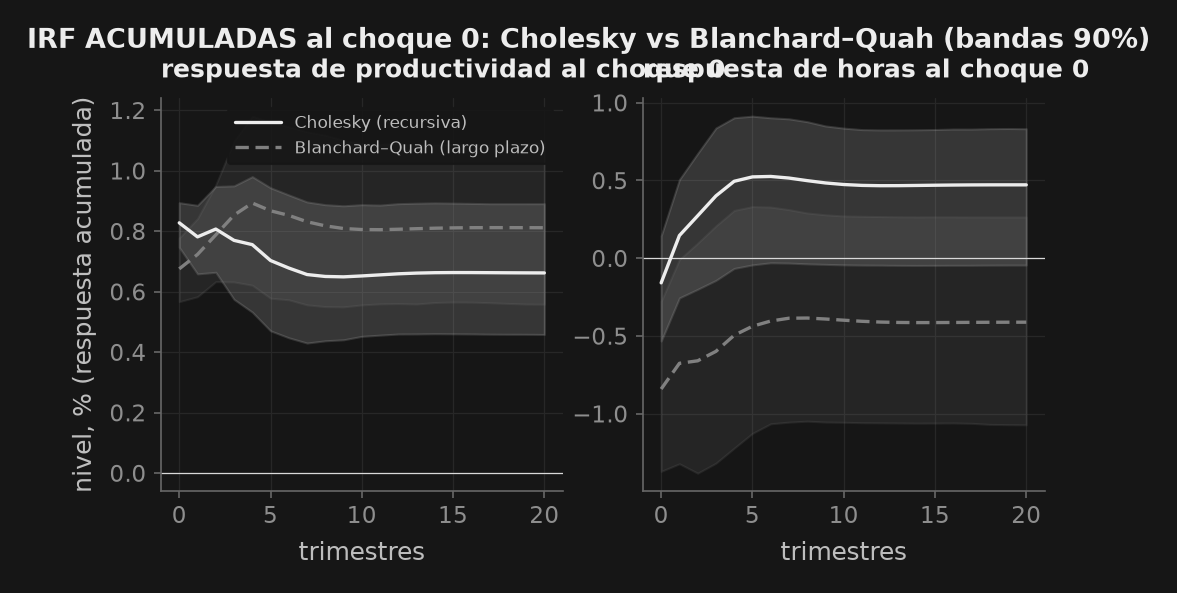

In [8]:
cols = _nbstyle.palette(2)
hh = np.arange(H + 1)
fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.4), sharex=True)
for k, ax in enumerate(axes):
    ax.axhline(0, color="0.85", lw=0.6)
    # Cholesky (acumulada, para que sea comparable con BQ)
    ax.plot(hh, ch_cum[:, k, 0], color=cols[0], lw=1.6, label="Cholesky (recursiva)")
    ax.fill_between(hh, ch_cum_lo[:, k, 0], ch_cum_hi[:, k, 0], color=cols[0], alpha=0.15)
    # Blanchard-Quah (ya viene acumulada)
    ax.plot(hh, bqr.irf_point[:, k, 0], color="0.50", lw=1.6, ls=(0, (4, 2)),
            label="Blanchard–Quah (largo plazo)")
    ax.fill_between(hh, bqr.irf_lower[:, k, 0], bqr.irf_upper[:, k, 0], color="0.50", alpha=0.15)
    ax.set_title(f"respuesta de {labels[k]} al choque 0")
    ax.set_xlabel("trimestres")
axes[0].set_ylabel("nivel, % (respuesta acumulada)")
axes[0].legend(loc="upper right", fontsize=8)
fig.suptitle("IRF ACUMULADAS al choque 0: Cholesky vs Blanchard–Quah (bandas 90%)", y=1.02)
plt.show()

### Lectura
Ya en unidades comparables, la **respuesta de las horas** separa a los dos esquemas.
Bajo **BQ**, un choque de tecnología positivo hace caer las horas en el impacto y el punto
estimado las mantiene por debajo de su nivel inicial en todo el horizonte: es el hallazgo
de Galí (1999), en tensión con la predicción del RBC de que las horas suben.
Bajo **Cholesky**, el impacto también es negativo, pero unas cinco veces menor, y desde el
segundo trimestre (h≥1) la respuesta acumulada se vuelve **positiva** y ahí se queda.
Es decir: la caída persistente de horas es un producto del supuesto de largo plazo, no
del dato.

**Honestidad estadística.** Solo el impacto y h=1 de BQ tienen la banda del 90 %
íntegramente por debajo de cero; a partir de h=2 la banda ya cruza el cero. Y la respuesta
acumulada positiva de Cholesky **nunca** tiene su banda enteramente por encima de cero.
Con dos series y ~300 trimestres, lo que la muestra distingue con firmeza es el **impacto**
bajo BQ; el resto del contraste vive en los puntos estimados, no en la inferencia.

Y no es que un esquema "acierte" y el otro "falle": el "choque 0" **no es el mismo objeto**
en los dos. En Cholesky es la innovación propia de la productividad definida por el
*timing*; en BQ es el único choque con efecto permanente sobre la productividad.
**La economía sale del supuesto, no del dato.**

## 7. Descomposición de varianza (FEVD)
La **FEVD** reparte la varianza del error de pronóstico de cada variable, a cada horizonte,
entre los choques estructurales. Con la matriz de impacto $B_0$ y `fevd(A_list, B0, H)`
obtenemos las cuotas (cada fila suma 1). Usamos la $B_0$ de Cholesky, que `puremacro`
expone como `cholesky_factor` (el factor triangular inferior de $\Sigma$).

**Qué se descompone.** Como $Y$ está en tasas de crecimiento, esta FEVD reparte la
varianza del error de pronóstico del **crecimiento** trimestral, no del nivel. La FEVD del
nivel exigiría acumular antes, y no es la que sale de `fevd`.

El segundo argumento de `irf`/`fevd` es la matriz de **impacto estructural** $B_0$,
**nunca** $\Sigma_u$: pasarle $\Sigma_u$ corre sin error y devuelve basura.

In [9]:
B0_chol = cholesky_factor(res.Sigma)        # factor de Cholesky = matriz de impacto recursiva
fev = fevd(res.A_list, B0_chol, H)          # fev[h, i, j] = cuota del choque j en Var(y_i,t+h)

for h in (0, 4, 20):
    print(f"h={h:2d} | productividad: choque0={fev[h,0,0]:.2f} choque1={fev[h,0,1]:.2f}"
          f"   | horas: choque0={fev[h,1,0]:.2f} choque1={fev[h,1,1]:.2f}")
assert np.allclose(fev.sum(axis=2), 1.0)    # las cuotas suman 1 en cada fila
assert abs(ch.irf_point[0, 0, 1]) < 1e-9    # restricción de impacto de Cholesky
assert abs(bqr.irf_point[H, 0, 1]) < 1e-2   # restricción de largo plazo de BQ
assert bqr.irf_point[0, 1, 0] < 0.0         # las horas caen ante el choque de tecnología
assert bq07.irf_point[0, 1, 0] < 0.0        # ... también en el corte pre-2008
assert bqr.irf_point[H, 1, 0] < 0.0         # BQ: horas por debajo del nivel inicial a h=H
assert ch_cum[H, 1, 0] > 0.0                # Cholesky acumulada: horas ARRIBA a h=H
assert ch_cum_lo[0, 1, 0] < 0.0 < ch_cum_hi[0, 1, 0]   # el impacto Cholesky abraza el cero

h= 0 | productividad: choque0=1.00 choque1=0.00   | horas: choque0=0.02 choque1=0.98
h= 4 | productividad: choque0=0.92 choque1=0.08   | horas: choque0=0.09 choque1=0.91
h=20 | productividad: choque0=0.91 choque1=0.09   | horas: choque0=0.09 choque1=0.91


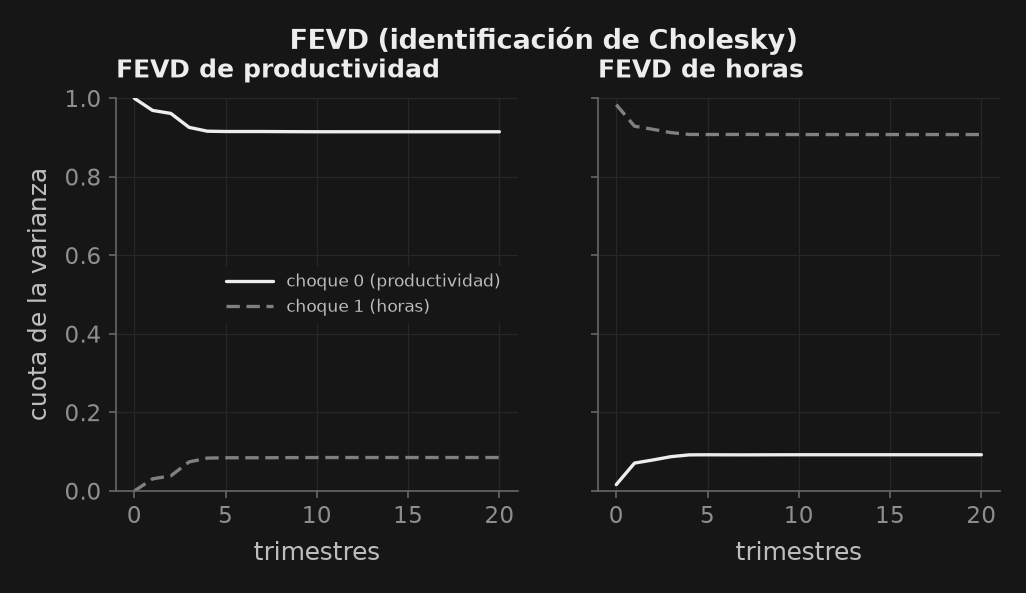

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.4), sharex=True, sharey=True)
for k, ax in enumerate(axes):
    ax.plot(hh, fev[:, k, 0], color=cols[0], lw=1.6, label="choque 0 (productividad)")
    ax.plot(hh, fev[:, k, 1], color="0.50", lw=1.6, ls=(0, (4, 2)), label="choque 1 (horas)")
    ax.set_title(f"FEVD de {labels[k]}")
    ax.set_xlabel("trimestres"); ax.set_ylim(0, 1)
axes[0].set_ylabel("cuota de la varianza")
axes[0].legend(loc="center right", fontsize=8)
fig.suptitle("FEVD (identificación de Cholesky)", y=1.02)
plt.show()

## 8. Leer el output: ¿qué identificación se usó?
Cada esquema deja una **huella** verificable en la IRF. Estas dos pruebas te dicen, a
partir del output, qué supuesto la generó:

In [11]:
# efecto de impacto (h=0) de la productividad al choque 1
imp_chol = ch.irf_point[0, 0, 1]
imp_bq = bqr.irf_point[0, 0, 1]
# efecto acumulado de largo plazo (BQ ya viene acumulada; Cholesky hay que acumularla)
lr_chol = np.cumsum(ch.irf_point[:, 0, 1])[H]
lr_bq = bqr.irf_point[H, 0, 1]

print("Prueba A — ¿efecto de impacto (h=0) forzado a cero?  ->  Cholesky (timing)")
print(f"   Cholesky  impacto  productividad<-choque1 = {imp_chol:+.4f}")
print(f"   BQ        impacto  productividad<-choque1 = {imp_bq:+.4f}")
print()
print("Prueba B — ¿efecto ACUMULADO de largo plazo forzado a cero?  ->  Blanchard–Quah")
print(f"   Cholesky  acumulado productividad<-choque1 = {lr_chol:+.4f}")
print(f"   BQ        acumulado productividad<-choque1 = {lr_bq:+.4f}")

Prueba A — ¿efecto de impacto (h=0) forzado a cero?  ->  Cholesky (timing)
   Cholesky  impacto  productividad<-choque1 = +0.0000
   BQ        impacto  productividad<-choque1 = +0.4785

Prueba B — ¿efecto ACUMULADO de largo plazo forzado a cero?  ->  Blanchard–Quah
   Cholesky  acumulado productividad<-choque1 = -0.4694
   BQ        acumulado productividad<-choque1 = -0.0003


### Diagnóstico
- Si **el efecto de impacto (h=0)** de un choque sobre otra variable es exactamente cero,
  la identificación es **recursiva (Cholesky)**: la huella es una restricción de *timing*
  contemporáneo.
- Si el efecto de impacto es no nulo pero **el efecto acumulado de largo plazo** converge a
  cero, la identificación es de **largo plazo (Blanchard–Quah)**: la huella está en el
  horizonte lejano, no en el impacto.
- Advertencia: la huella es *necesaria*, no *suficiente*. Un cero de impacto también
  aparece bajo restricciones de signo-y-cero o en un proxy-SVAR que imponga exclusiones
  contemporáneas. La huella descarta esquemas; para saber cuál se usó hay que leer el

## 8b. Triangulación con restricciones de signo y tablas de publicación

Una tercera familia de identificación impone **restricciones de signo** (Rubio-Ramírez,
Waggoner y Zha 2010; `puremacro.var.identify.sign.sign_restriction_svar`): en lugar de fijar
coeficientes exactos en cero, se restringe la dirección de la respuesta contemporánea o a
horizontes cortos.

Para identificar el choque de tecnología imponemos únicamente que una innovación tecnológica
eleve la **productividad laboral** en el impacto ($h=0$, signo $+1$), dejando la respuesta de
las horas **libre** (signo $0$). Evaluamos si la caída de horas encontrada por Galí (1999)
sobrevive bajo este esquema agnóstico, y exportamos una tabla comparativa de publicación
con `puremacro.reports`.

In [12]:
from puremacro.var.identify.sign import sign_restriction_svar
from puremacro.reports import df_to_markdown, df_to_latex

# Restricción: columna 0 (tecnología) eleva productividad (+1) en h=0; horas libre (0)
res_sign = sign_restriction_svar(Y, p=p, horizon=H, restrictions={0: [1, 0]}, n_draws=1000, seed=7)
sign_cum_hours = np.cumsum(res_sign.irf_median[:, 1, 0])

horizons_tab = [0, 1, 4, 8, 12, 20]
comp_df = pd.DataFrame({
    "h": horizons_tab,
    "Cholesky (Acum.)": [ch_cum[h, 1, 0] for h in horizons_tab],
    "Blanchard-Quah": [bqr.irf_point[h, 1, 0] for h in horizons_tab],
    "Sign (RRWZ 2010)": [sign_cum_hours[h] for h in horizons_tab],
})

print(f"Restricciones de signo aceptadas: {res_sign.n_accepted}/{res_sign.n_draws} sorteos Haar.")
print("\n--- Tabla comparativa de la respuesta de horas al choque de tecnología (Markdown) ---")
print(df_to_markdown(comp_df, digits=3))

assert res_sign.n_accepted > 100
assert res_sign.irf_median[0, 0, 0] > 0.0      # productividad sube por restricción
assert res_sign.irf_median[0, 1, 0] < 0.0      # horas caen en el impacto aún bajo signo puro agnóstico

Restricciones de signo aceptadas: 502/1000 sorteos Haar.

--- Tabla comparativa de la respuesta de horas al choque de tecnología (Markdown) ---
|  h | Cholesky (Acum.) | Blanchard-Quah | Sign (RRWZ 2010) |
|----|------------------|----------------|------------------|
|  0 |           -0.158 |         -0.841 |           -0.160 |
|  1 |            0.146 |         -0.676 |            0.083 |
|  4 |            0.495 |         -0.495 |            0.389 |
|  8 |            0.499 |         -0.385 |            0.394 |
| 12 |            0.467 |         -0.410 |            0.367 |
| 20 |            0.472 |         -0.411 |            0.372 |


## 9. Preguntas para pensar
1. La FEVD (del **crecimiento**) atribuye a la productividad casi toda su propia varianza,
   pero al choque de productividad solo ~9 % de la varianza de las horas. ¿Qué te dice eso
   sobre qué mueve a cada variable en el corto plazo?
2. En Cholesky, invertir el orden a `[horas, productividad]` cambia los choques. ¿Bajo qué
   supuesto económico sería *defendible* poner las horas primero?
3. El resultado de Galí (horas que caen ante un choque de tecnología) desafía al RBC
   básico. ¿Confías más en la huella de largo plazo (BQ) o en la de timing (Cholesky) para
   identificar "tecnología"? ¿Por qué?

## 10. Explora con IA
Prueba estos prompts con el tutor sin conexión (o cualquier asistente de IA):

In [13]:
print(tutor(
    "En dos frases: ¿en qué se diferencia el supuesto de identificación de Cholesky "
    "(recursivo/contemporáneo) del de Blanchard–Quah (largo plazo) en un SVAR?"
))

[tutor sin conexión] No hay ningún motor de LLM local disponible en esta instalación (el tutor es opcional). Puedes instalar uno con `pip install puremacro[local-llm]` más un modelo pequeño (por ejemplo vía Ollama o MLX), o bien usar las indicaciones de la sección «Explora con IA» de esta lección con cualquier asistente de IA.
(motivo: el motor local no está disponible)


**Resumen.** Un VAR reducido pronostica pero no identifica: $\Sigma = B_0 B_0'$ deja a
$B_0$ indeterminado salvo rotación. **Cholesky** cierra el sistema con ceros de *timing*
contemporáneo (impacto triangular); **Blanchard–Quah** lo cierra con un cero de **largo
plazo** (impacto acumulado triangular). Sobre los datos de Galí (1999), y comparadas en
las **mismas unidades** (ambas acumuladas), las dos IRF difieren: BQ recupera el hallazgo
de las horas que caen y siguen abajo, mientras la Cholesky acumulada las devuelve a
terreno positivo desde el segundo trimestre. La **FEVD** reparte, a su vez, la varianza
del pronóstico del crecimiento entre choques. Dos advertencias de oficio: comparar IRF
exige igualar acumulación, y la magnitud del resultado de Galí depende de la muestra
(−0.84 % con datos hasta 2026 frente a −0.24 % con el corte pre-2008 del debate; el signo
aguanta, el tamaño no). La lección central: **la conclusión económica sale del supuesto
identificador, no solo del dato.** Todo con `puremacro.var` (Python puro), sobre tu
instalación local.